In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"



I_POS_mA = +10.0
I_NEG_mA = -10.0

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

mu0 = 4 * np.pi * 1e-7  # T m / A


# x = magnet line / horizontal image axis
# y = approximate wire direction / vertical image axis
# z = optical axis
#
# theta = 0° means current along +y.
# theta > 0° means current tilts toward +x as y increases.


WIRE_THETA_DEG = 8.0
WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

# Sensor depth below the wire plane
SENSOR_DEPTH_UM =35

# You found +1 gives the correct Bx sign.
SENSOR_Z_SIGN = +1.0

# Finite source geometry
WIRE_LENGTH_UM = 500.0
CYLINDER_RADIUS_UM = 10

# Numerical resolution
N_FILAMENT_POINTS = 301
N_CYLINDER_LENGTH = 101
N_CYLINDER_CROSS = 11

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

print("Simulation setup")
print("----------------")
print("I_POS_mA:", I_POS_mA)
print("I_NEG_mA:", I_NEG_mA)
print("SENSOR_DEPTH_UM:", SENSOR_DEPTH_UM)
print("SENSOR_Z_SIGN:", SENSOR_Z_SIGN)
print("WIRE_THETA_DEG:", WIRE_THETA_DEG)
print("WIRE_X0_UM:", WIRE_X0_UM)
print("WIRE_Y0_UM:", WIRE_Y0_UM)
print("WIRE_LENGTH_UM:", WIRE_LENGTH_UM)
print("CYLINDER_RADIUS_UM:", CYLINDER_RADIUS_UM)


Simulation setup
----------------
I_POS_mA: 10.0
I_NEG_mA: -10.0
SENSOR_DEPTH_UM: 25
SENSOR_Z_SIGN: 1.0
WIRE_THETA_DEG: 8.0
WIRE_X0_UM: 20.0
WIRE_Y0_UM: 0.0
WIRE_LENGTH_UM: 500.0
CYLINDER_RADIUS_UM: 10


In [71]:
# load B-results fiel

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "pixel", "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"B_results.csv is missing columns: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

print("Loaded measured data")
print("grid:", grid_size, "x", grid_size)
print("extent_um:", extent_um)

if "POS_time_actual_s" in B_df.columns:
    print("POS time [s]:", B_df["POS_time_actual_s"].iloc[0])
if "NEG_time_actual_s" in B_df.columns:
    print("NEG time [s]:", B_df["NEG_time_actual_s"].iloc[0])


Loaded measured data
grid: 31 x 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
POS time [s]: 0.0625968
NEG time [s]: 0.0571872


## wire models biot approx and cylindrical wire 2 functions


SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [72]:
# ============================================================
# Function 1: finite-filament Biot-Savart approximation
# ============================================================

def simulate_biot_filament(
    x_um,
    y_um,
    I_A,
    depth_um,
    length_um=500.0,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
    sensor_z_sign=+1.0,
    n_points=301,
):
    """
    Numerical Biot-Savart field of a finite tilted current filament.

    Returns:
        B_nT with shape (3, Ny, Nx), ordered as [Bx, By, Bz].
    """

    theta = np.deg2rad(theta_deg)

    ux = np.sin(theta)
    uy = np.cos(theta)
    uz = 0.0

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = sensor_z_sign * depth_um * 1e-6 * np.ones_like(X)

    s_um = np.linspace(-length_um / 2, length_um / 2, n_points)
    ds_m = (s_um[1] - s_um[0]) * 1e-6

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 * I_A / (4 * np.pi)

    for s in s_um:
        xs = (x0_um + s * ux) * 1e-6
        ys = (y0_um + s * uy) * 1e-6
        zs = 0.0

        Rx = X - xs
        Ry = Y - ys
        Rz = Z - zs

        R2 = Rx**2 + Ry**2 + Rz**2
        R = np.sqrt(R2)
        R3 = np.where(R < 1e-15, 1e-45, R**3)

        dlx = ux * ds_m
        dly = uy * ds_m
        dlz = uz * ds_m

        cross_x = dly * Rz - dlz * Ry
        cross_y = dlz * Rx - dlx * Rz
        cross_z = dlx * Ry - dly * Rx

        Bx_T += prefactor * cross_x / R3
        By_T += prefactor * cross_y / R3
        Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)


# ============================================================
# Function 2: finite cylindrical-wire Biot-Savart approximation
# ============================================================

def simulate_cylindrical_wire(
    x_um,
    y_um,
    I_A,
    depth_um,
    radius_um=20.0,
    length_um=500.0,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
    sensor_z_sign=+1.0,
    n_length=101,
    n_cross=11,
):
    """
    Numerical Biot-Savart field of a finite cylindrical current distribution.

    The cylinder carries uniform current density along its axis.

    Returns:
        B_nT with shape (3, Ny, Nx), ordered as [Bx, By, Bz].
    """

    theta = np.deg2rad(theta_deg)

    ux = np.sin(theta)
    uy = np.cos(theta)
    uz = 0.0

    # In-plane perpendicular direction to the cylinder axis.
    px = uy
    py = -ux
    pz = 0.0

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = sensor_z_sign * depth_um * 1e-6 * np.ones_like(X)

    radius_m = radius_um * 1e-6
    length_m = length_um * 1e-6

    area_m2 = np.pi * radius_m**2
    J_A_per_m2 = I_A / area_m2

    s_um = np.linspace(-length_um / 2, length_um / 2, n_length)

    q_um = np.linspace(-radius_um, radius_um, n_cross)
    zc_um = np.linspace(-radius_um, radius_um, n_cross)

    cross_offsets = []

    for q in q_um:
        for zc in zc_um:
            if q**2 + zc**2 <= radius_um**2:
                cross_offsets.append((q, zc))

    cross_offsets = np.array(cross_offsets)

    if len(cross_offsets) == 0:
        raise ValueError("No cross-section points selected. Increase n_cross.")

    dV = area_m2 * length_m / (len(cross_offsets) * n_length)

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 / (4 * np.pi)

    for s in s_um:
        for q, zc in cross_offsets:
            xs_um = x0_um + s * ux + q * px
            ys_um = y0_um + s * uy + q * py
            zs_um = zc

            xs = xs_um * 1e-6
            ys = ys_um * 1e-6
            zs = zs_um * 1e-6

            Rx = X - xs
            Ry = Y - ys
            Rz = Z - zs

            R2 = Rx**2 + Ry**2 + Rz**2
            R = np.sqrt(R2)
            R3 = np.where(R < 1e-15, 1e-45, R**3)

            JdVx = J_A_per_m2 * dV * ux
            JdVy = J_A_per_m2 * dV * uy
            JdVz = J_A_per_m2 * dV * uz

            cross_x = JdVy * Rz - JdVz * Ry
            cross_y = JdVz * Rx - JdVx * Rz
            cross_z = JdVx * Ry - JdVy * Rx

            Bx_T += prefactor * cross_x / R3
            By_T += prefactor * cross_y / R3
            Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

In [73]:
# ============================================================
# Simulate POS and NEG fields with fixed geometry
# ============================================================

B_pos_sim_biot = simulate_biot_filament(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=SENSOR_DEPTH_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
    n_points=N_FILAMENT_POINTS,
)

B_neg_sim_biot = simulate_biot_filament(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=SENSOR_DEPTH_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
    n_points=N_FILAMENT_POINTS,
)

B_pos_sim_cyl = simulate_cylindrical_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=SENSOR_DEPTH_UM,
    radius_um=CYLINDER_RADIUS_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
    n_length=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
)

B_neg_sim_cyl = simulate_cylindrical_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=SENSOR_DEPTH_UM,
    radius_um=CYLINDER_RADIUS_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
    n_length=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
)

print("Simulated fields with fixed geometry")
print("------------------------------------")

for name, Bpos in [
    ("Biot filament", B_pos_sim_biot),
    ("Cylindrical wire", B_pos_sim_cyl),
]:
    print("\n", name)
    for i, comp in enumerate(B_COMPONENTS):
        print(comp, "POS p95 [nT] =", np.nanpercentile(np.abs(Bpos[i]), 95))

Simulated fields with fixed geometry
------------------------------------

 Biot filament
Bx POS p95 [nT] = 75058.51929447049
By POS p95 [nT] = 10548.78695317044
Bz POS p95 [nT] = 39266.184809318

 Cylindrical wire
Bx POS p95 [nT] = 74284.27756897792
By POS p95 [nT] = 10439.974374808202
Bz POS p95 [nT] = 38902.431308690895


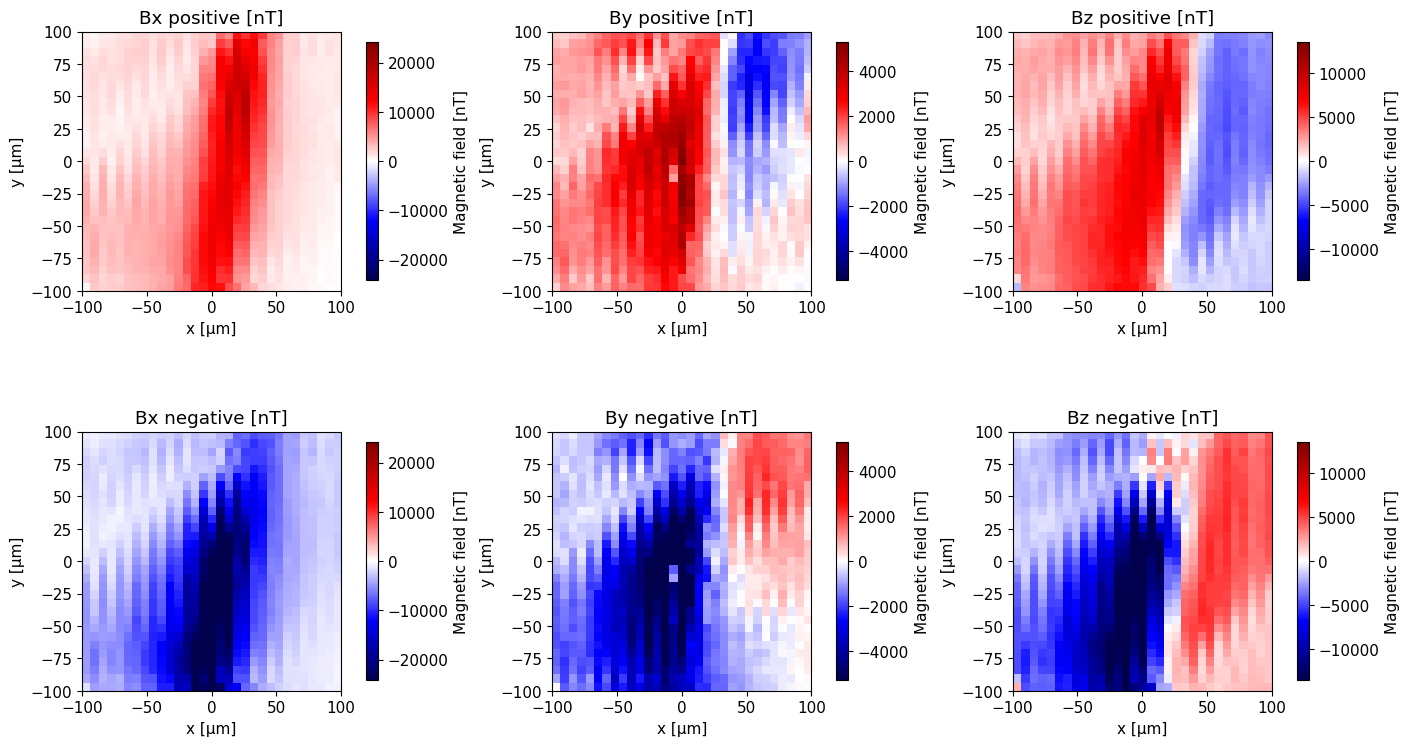

In [74]:
# ============================================================
# Plot measured B maps in the same style as the pulse file
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_neg_meas[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"{comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04).set_label("Magnetic field [nT]")

    im1 = axes[1, i].imshow(
        B_neg_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"{comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04).set_label("Magnetic field [nT]")

plt.show()

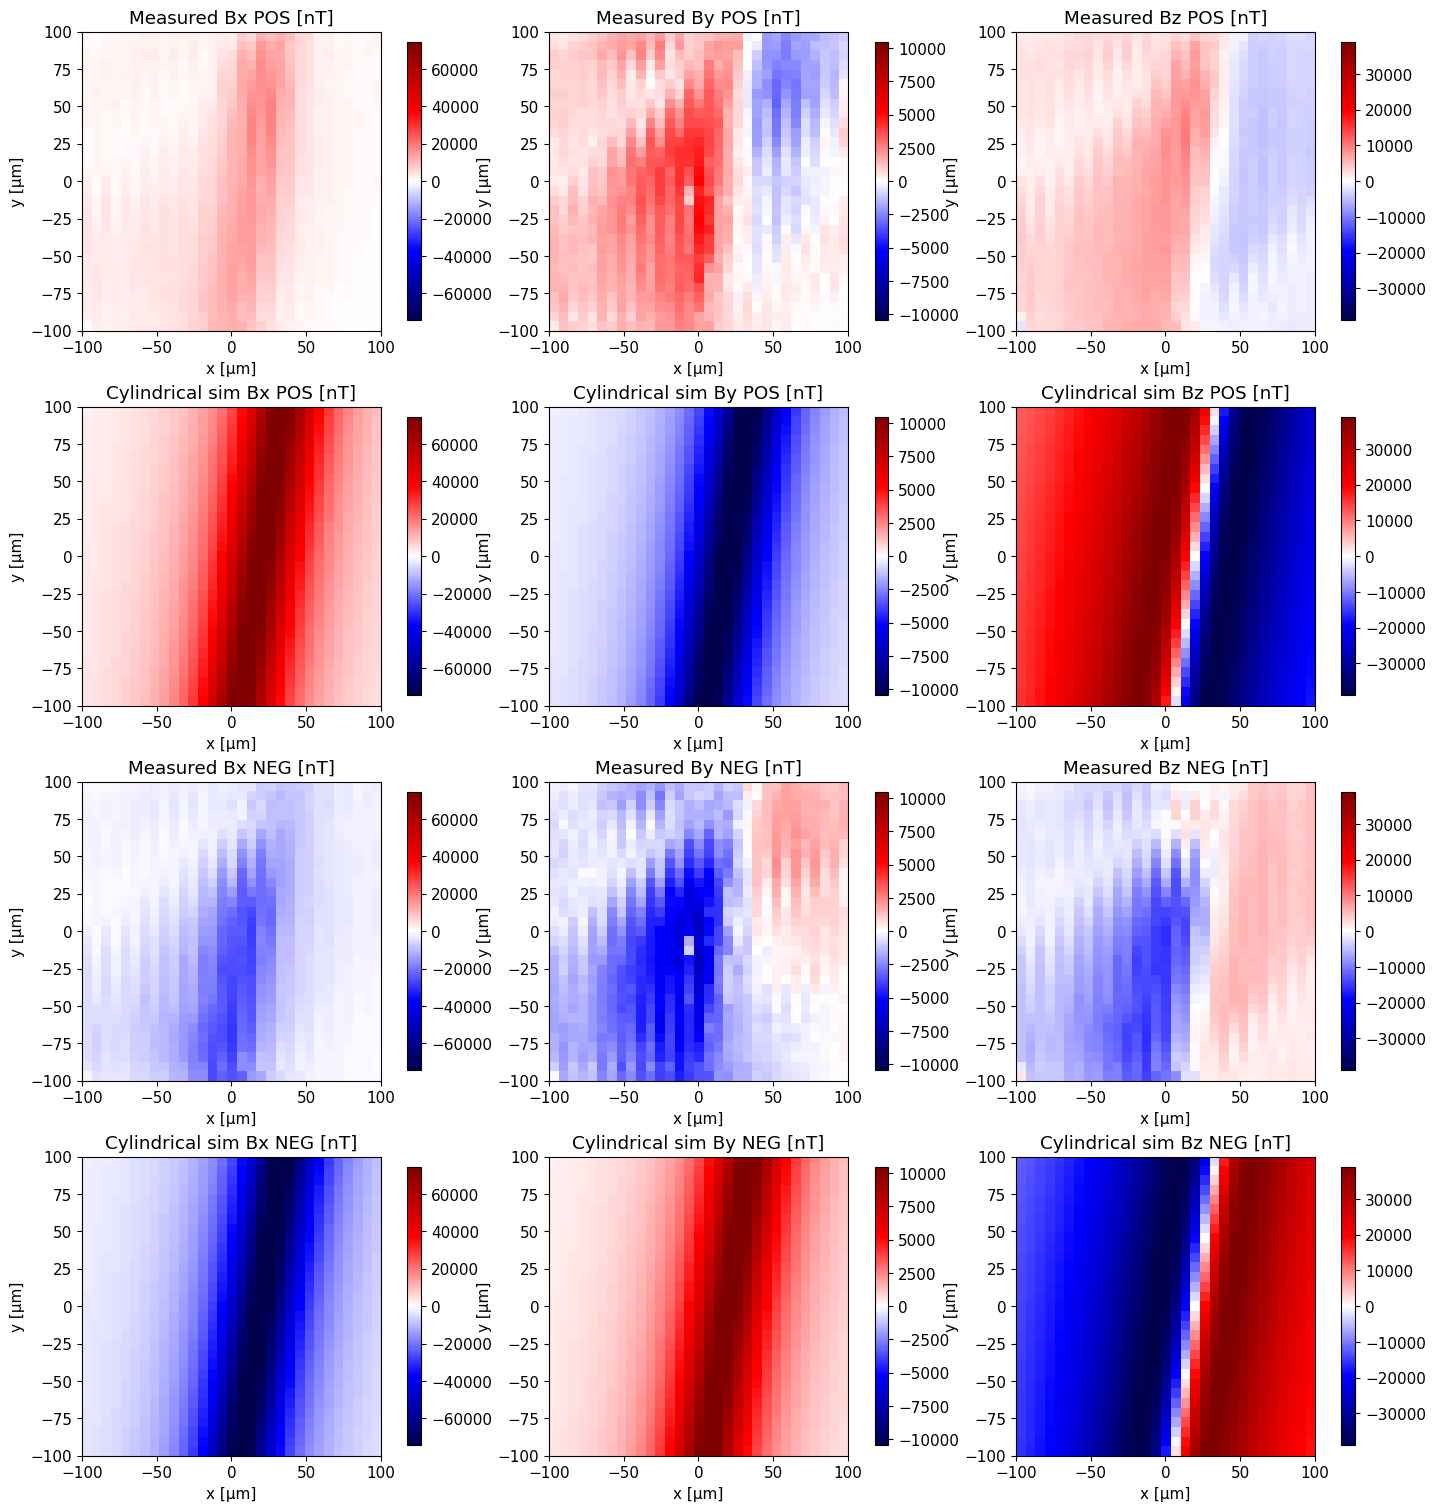

In [77]:
# ============================================================
# Direct comparison: measured vs cylindrical-wire simulation
# No scaling. Current remains fixed at ±10 mA.
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(14, 15), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_neg_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim_cyl[i]), 95),
        np.nanpercentile(np.abs(B_neg_sim_cyl[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    maps = [
        (B_pos_meas[i], f"Measured {comp} POS [nT]"),
        (B_pos_sim_cyl[i], f"Cylindrical sim {comp} POS [nT]"),
        (B_neg_meas[i], f"Measured {comp} NEG [nT]"),
        (B_neg_sim_cyl[i], f"Cylindrical sim {comp} NEG [nT]"),
    ]

    for row_i, (data, title) in enumerate(maps):
        im = axes[row_i, i].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-lim,
            vmax=lim,
        )
        axes[row_i, i].set_title(title)
        axes[row_i, i].set_xlabel("x [µm]")
        axes[row_i, i].set_ylabel("y [µm]")
        plt.colorbar(im, ax=axes[row_i, i], fraction=0.046, pad=0.04)

plt.show()

In [76]:
# ============================================================
# Direct comparison table
# No amplitude scaling. Current remains fixed at ±10 mA.
# ============================================================

comparison_rows = []

model_dict = {
    "biot_filament": (B_pos_sim_biot, B_neg_sim_biot),
    "cylindrical_wire": (B_pos_sim_cyl, B_neg_sim_cyl),
}

for model_name, (Bpos_sim, Bneg_sim) in model_dict.items():
    for i, comp in enumerate(B_COMPONENTS):
        for phase, meas_map, sim_map in [
            ("POS", B_pos_meas[i], Bpos_sim[i]),
            ("NEG", B_neg_meas[i], Bneg_sim[i]),
        ]:
            meas = meas_map.ravel()
            sim = sim_map.ravel()

            mask = np.isfinite(meas) & np.isfinite(sim)

            if np.nanstd(meas[mask]) > 0 and np.nanstd(sim[mask]) > 0:
                corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
            else:
                corr = np.nan

            rms_res = np.sqrt(np.nanmean((meas[mask] - sim[mask])**2))

            comparison_rows.append({
                "model": model_name,
                "component": comp,
                "phase": phase,
                "measured_p95_abs_nT": np.nanpercentile(np.abs(meas), 95),
                "simulated_p95_abs_nT": np.nanpercentile(np.abs(sim), 95),
                "sim_over_meas_p95": (
                    np.nanpercentile(np.abs(sim), 95)
                    / np.nanpercentile(np.abs(meas), 95)
                ),
                "rms_residual_nT": rms_res,
                "corr_meas_sim": corr,
            })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,model,component,phase,measured_p95_abs_nT,simulated_p95_abs_nT,sim_over_meas_p95,rms_residual_nT,corr_meas_sim
0,biot_filament,Bx,POS,13433.715457,75058.519294,5.587324,28440.907050,0.891478
1,biot_filament,Bx,NEG,24199.039109,75058.519294,3.101715,25665.391870,0.746604
2,biot_filament,By,POS,3673.775926,10548.786953,2.871375,5872.012526,-0.100124
3,biot_filament,By,NEG,5308.921674,10548.786953,1.986992,6471.286785,-0.210936
4,biot_filament,Bz,POS,7395.124460,39266.184809,5.309740,25019.297104,0.865046
5,biot_filament,Bz,NEG,13584.200569,39266.184809,2.890578,23702.472157,0.808150
6,cylindrical_wire,Bx,POS,13433.715457,74284.277569,5.529690,28105.980112,0.891465
7,cylindrical_wire,Bx,NEG,24199.039109,74284.277569,3.069720,25335.335632,0.746636
8,cylindrical_wire,By,POS,3673.775926,10439.974375,2.841756,5826.855657,-0.100130
9,cylindrical_wire,By,NEG,5308.921674,10439.974375,1.966496,6426.769057,-0.211002
